(example_resample)=

# Resample dataset

Resampling your dataset, such as upscaling or downscaling, is supported in the `resample` method of datasets in `faninsar`. This method accepts a `new_res` argument, which can be a single value or a tuple of values. 

In [ ]:
from faninsar import datasets, cmaps
from faninsar.constants import Resampling
import matplotlib.pyplot as plt

In [27]:
file_hyp3 = "/Volumes/Data/Github/FanInSAR/tests/data/HyP3_ALOS2_Amplitude/HyP3_Amplitude.tif"

ds_hyp3 = datasets.RasterDataset(paths=[file_hyp3])

In [21]:
ds_hyp3_upscale = ds_hyp3.resample(
    new_res=ds_hyp3.res[0]*4,
    resampling=Resampling.bilinear,
)

ds_hyp3_downscale = ds_hyp3.resample(
    new_res=(ds_hyp3.res[0]/4, ds_hyp3.res[1]/4),
    resampling=Resampling.bilinear,
)

In [22]:
print("Original resolution:", ds_hyp3.res, "shape:", ds_hyp3.shape)
print("Upscaled resolution:", ds_hyp3_upscale.res, "shape:", ds_hyp3_upscale.shape)
print("Downscaled resolution:", ds_hyp3_downscale.res, "shape:", ds_hyp3_downscale.shape)

Original resolution: (40.0, 40.0) shape: (147, 97)
Upscaled resolution: (160.0, 160.0) shape: (37, 24)
Downscaled resolution: (10.0, 10.0) shape: (588, 388)


In [23]:
arr = ds_hyp3[ds_hyp3.bounds].boxes.data
arr_upscaled = ds_hyp3_upscale[ds_hyp3.bounds].boxes.data
arr_downscaled = ds_hyp3_downscale[ds_hyp3.bounds].boxes.data

Loading  Files: 100%|██████████| 1/1 [00:00<00:00, 139.00 files/s]


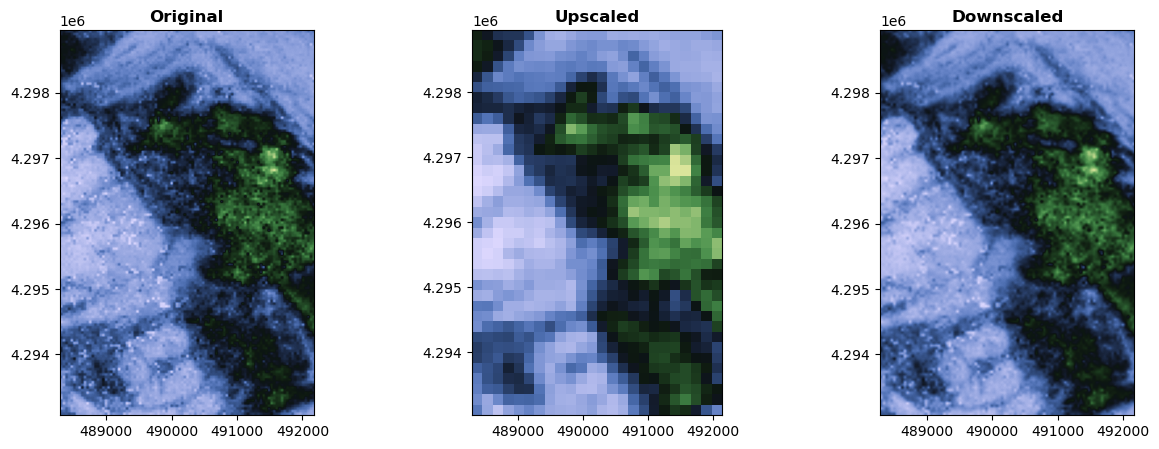

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

ds_hyp3.show(arr, ax=axs[0], title="Original", cmap=cmaps.tofino)
ds_hyp3_upscale.show(arr_upscaled, ax=axs[1], title="Upscaled", cmap=cmaps.tofino)
ds_hyp3_downscale.show(arr_downscaled, ax=axs[2], title="Downscaled", cmap=cmaps.tofino)